# Section 1: Data Cleaning and Validation

In [1]:
#Importing Libraries for use

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Reading csv file into a dataframe using pandas and preview

data = pd.read_csv("data.csv")
data.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [3]:
# Check data types and non-null counts for each column

data.info() 
data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


batch_id                      0
instructor_id                 0
course_id                     0
completion_rate               0
avg_score_improvement         0
avg_quiz_score                0
dropout_rate                  0
avg_watch_time                0
assignment_submission_rate    0
forum_activity_rate           0
avg_feedback_score            0
feedback_response_rate        0
dtype: int64

In [4]:
# Descriptive statistical summary of data for range validation of metrics

data.describe()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.159667,5.716641,10.695618,0.162747,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.300000,6.159240,40.386725,0.020000,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.489260,23.124673,70.897590,0.280035,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.603091,26.938629,78.020567,0.394820,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.712797,30.885600,85.444286,0.511432,0.894242,0.856458,0.319204,4.503437,0.845876
max,0.980000,40.000000,100.000000,0.700000,1.000000,1.000000,0.641111,5.000000,1.000000


In [5]:
# Expected valid ranges for each metric

expected_ranges = {
    'completion_rate': (0, 1),
    'dropout_rate': (0, 1),
    'avg_watch_time': (0, 1),
    'assignment_submission_rate': (0, 1),
    'forum_activity_rate': (0, 1),
    'feedback_response_rate': (0, 1),
    'avg_feedback_score': (1, 5),
}

# Check each column against its expected range

for col, (low, high) in expected_ranges.items():
    within_range = data[col].between(low, high).all()
    print(f"{col}: within [{low}, {high}] -> {within_range}")

completion_rate: within [0, 1] -> True
dropout_rate: within [0, 1] -> True
avg_watch_time: within [0, 1] -> True
assignment_submission_rate: within [0, 1] -> True
forum_activity_rate: within [0, 1] -> True
feedback_response_rate: within [0, 1] -> True
avg_feedback_score: within [1, 5] -> True


In [6]:
# Checking Batch_id column for duplicates

data['batch_id'].nunique()

2000

In [7]:
# Checking dataframe for duplicate rows (redundant as batch id comes out unique)

print(data.duplicated().sum())

0


In [8]:
# Checking instructor_id and course_id columns for case-sensitive uniqueness

print(data['instructor_id'].str.upper().nunique())
print(data['course_id'].str.upper().nunique())

120
25


In [9]:
data[['completion_rate','dropout_rate']].corr()

,completion_rate,dropout_rate
completion_rate,1.000000,-0.953493
dropout_rate,-0.953493,1.000000


## Data Cleaning

Before defining instructor effectiveness, I checked the dataset for common data 
quality issues: missing values, out-of-range values, duplicate records, and 
identifier consistency.

**Missing values**: None. Every column in the dataset had zero null values 
(`df.isnull().sum()`), so no imputation or row-dropping was required.

**Range validation**: I checked the min/max of every metric against its expected 
valid range as described in the handbook (e.g., rates between 0–1, feedback 
score between 1–5). All values fell within their expected bounds — no invalid 
or out-of-range entries were found.

**Duplicates**: `batch_id` is unique across all 2000 rows, confirming there are 
no duplicate batch records.

**Identifier consistency**: `instructor_id` and `course_id` values follow a 
consistent format and length across all rows, with no obvious formatting 
inconsistencies (e.g., casing mismatches) that would cause the same instructor 
or course to be split into separate groups.

**Redundant features**: `completion_rate` and `dropout_rate` showed a strong 
negative correlation (-0.95). While not perfectly collinear — implying some 
learners are neither "completed" nor "dropped out" (e.g., still in progress) — 
the two variables capture largely the same underlying signal. Including both 
in the effectiveness score would over-weight this signal relative to other 
metrics. I chose to retain `completion_rate` and exclude `dropout_rate` from 
further analysis, since completion is the more direct, intuitive measure of 
learner outcomes.

**Conclusion**: The dataset required no traditional cleaning (no missing data, 
no invalid values, no duplicates). The main pre-modeling decision was handling 
the completion/dropout redundancy, which I treated as a feature selection 
choice rather than a cleaning issue.

# Section 2: Exploratory Data Analysis and Visualisation

In [10]:
# General summary statistics 

data.describe()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.159667,5.716641,10.695618,0.162747,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.300000,6.159240,40.386725,0.020000,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.489260,23.124673,70.897590,0.280035,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.603091,26.938629,78.020567,0.394820,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.712797,30.885600,85.444286,0.511432,0.894242,0.856458,0.319204,4.503437,0.845876
max,0.980000,40.000000,100.000000,0.700000,1.000000,1.000000,0.641111,5.000000,1.000000


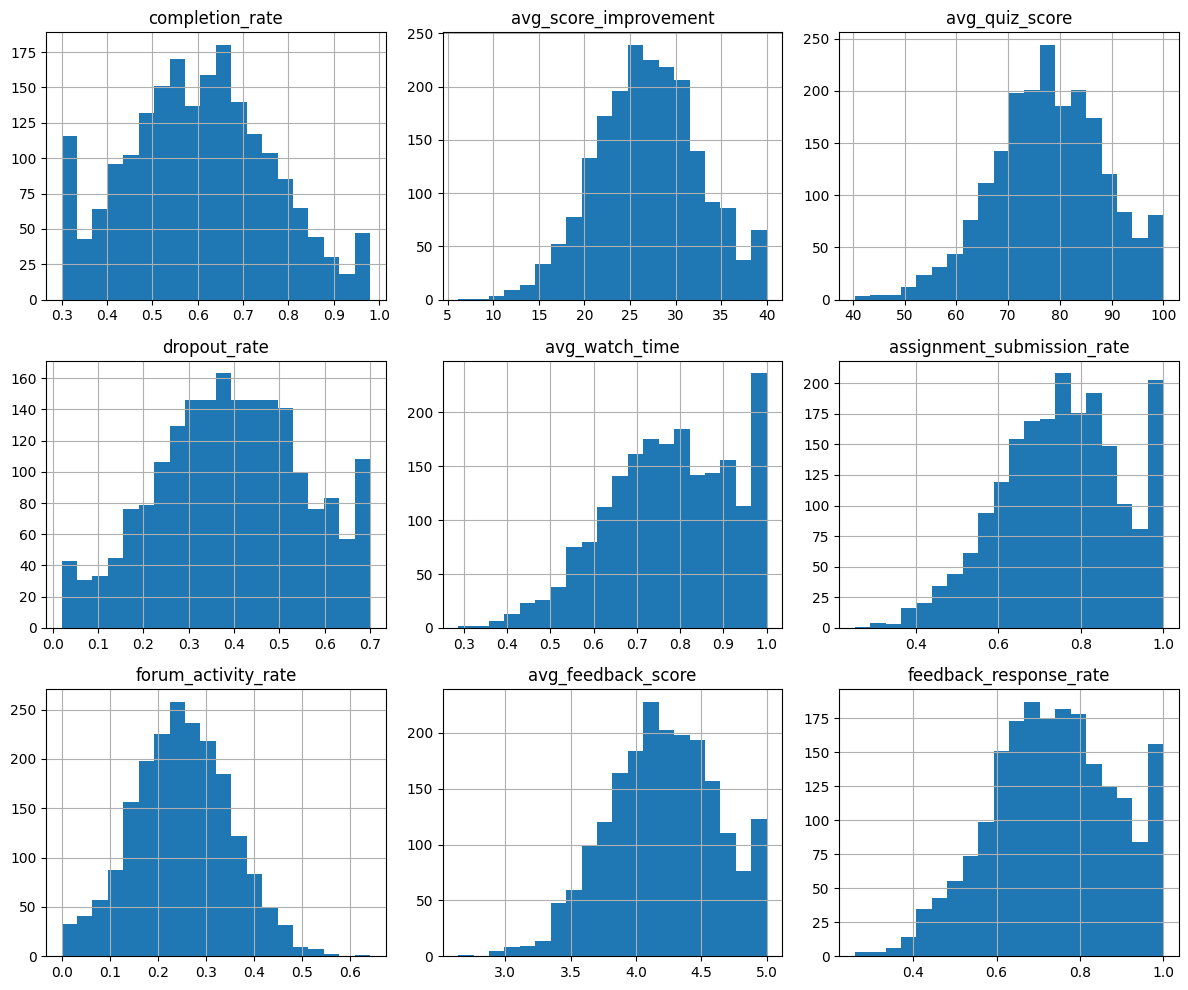

In [11]:
# Plotting histograms for each metric to identify patterns and information

data.hist(figsize=(12, 10), bins=20)
plt.tight_layout()
plt.savefig('metrics_plot.png')
plt.show()

### Distribution Observations

Most metrics (`avg_quiz_score`, `avg_feedback_score`, `avg_score_improvement`) 
are reasonably symmetric and bell-shaped. `avg_watch_time` is notably 
left-skewed, with a large cluster of batches near the ceiling (~1.0), 
suggesting limited ability to distinguish instructors on this metric alone. 
`completion_rate` shows small spikes near both its minimum and maximum, 
rather than a smooth single peak, worth keeping in mind during later analysis.

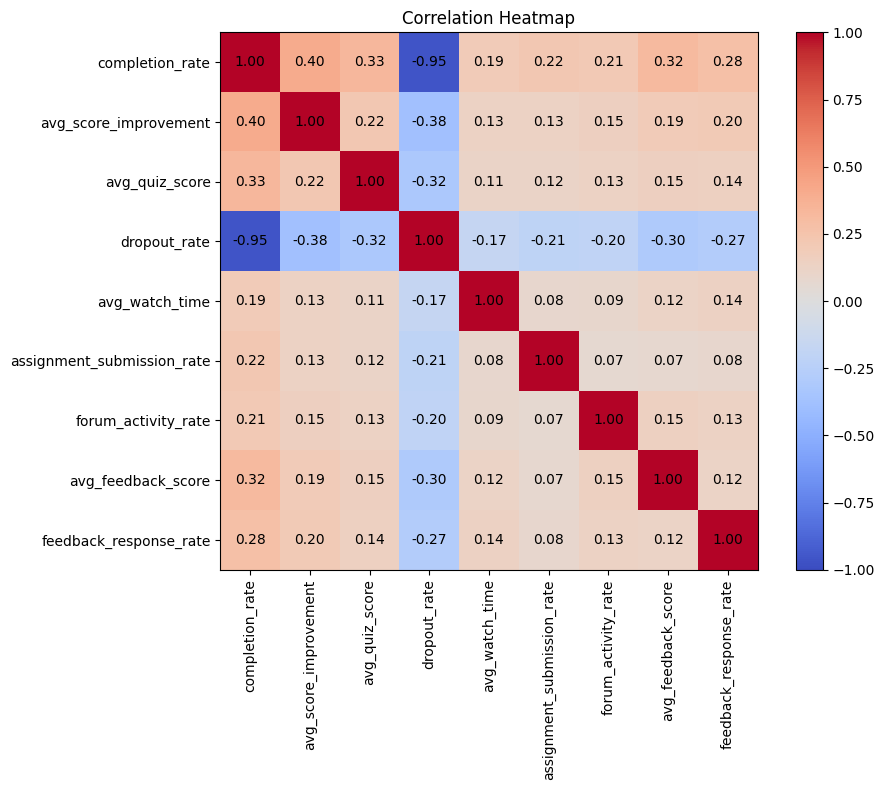

In [12]:
# Plotting a correlation heatmap for all given metrics to identify trends apart from the completion rate and drop rate 

corr = data.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

# axis labels

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)

# Colorbar
fig.colorbar(im, ax=ax)

# Annotate each cell with the correlation value
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black")

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig('heatmap.png')
plt.show()

### Correlation Observations

`completion_rate` and `dropout_rate` show a strong negative correlation 
(-0.95), indicating largely redundant information — `dropout_rate` was 
excluded from further analysis as a result. All other metric pairs show 
weak-to-moderate correlations (mostly 0.1–0.4), suggesting the remaining 
features carry relatively independent signal and are each contributing 
distinct information to instructor effectiveness.

In [13]:
# Group by course_id and look at average completion_rate per course

course_avg = data.groupby('course_id')['completion_rate'].mean().sort_values()
print(course_avg)

course_id
C_09    0.561902
C_08    0.571638
C_22    0.574229
C_16    0.580683
C_19    0.589855
C_15    0.590982
C_03    0.592443
C_13    0.592635
C_10    0.592842
C_23    0.593806
C_04    0.597575
C_07    0.598774
C_18    0.599867
C_02    0.601831
C_12    0.606735
C_17    0.607274
C_11    0.607435
C_01    0.611400
C_25    0.616483
C_24    0.617382
C_06    0.622184
C_21    0.625749
C_05    0.630338
C_14    0.639152
C_20    0.639422
Name: completion_rate, dtype: float64


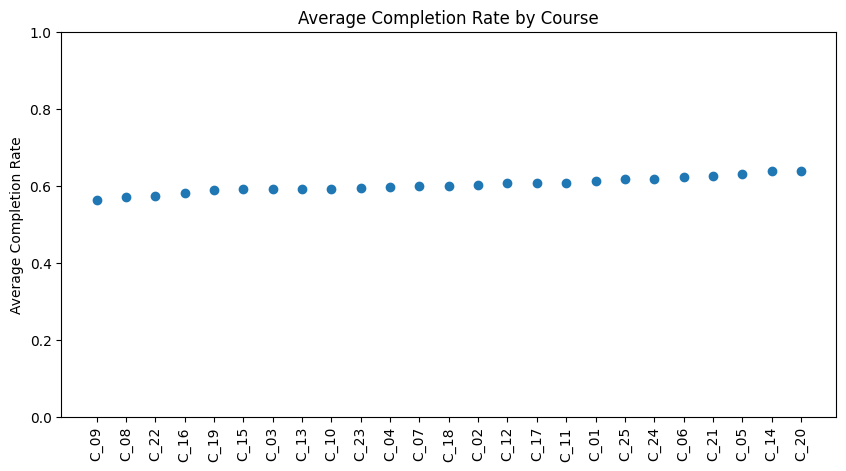

In [14]:
# Plotting a scatter chart for avg_completion_rate per course

plt.figure(figsize=(10,5))
plt.scatter(course_avg.index, course_avg.values)
plt.ylabel('Average Completion Rate')
plt.title('Average Completion Rate by Course')
plt.xticks(rotation=90)
plt.ylim(0, 1) 
plt.savefig('Avg_Completion_Rate_per_Course.png')
plt.show()

In [15]:
# Group by course_id and look at average quiz_score per course

course_quiz = data.groupby('course_id')['avg_quiz_score'].mean().sort_values()
print(course_quiz)

course_id
C_16    76.146757
C_07    76.570166
C_17    76.594139
C_19    76.714415
C_08    76.880615
C_05    76.924427
C_03    77.091312
C_09    77.106312
C_23    77.109156
C_01    77.458578
C_18    77.770557
C_12    77.824460
C_14    78.071778
C_15    78.112734
C_22    78.160854
C_13    78.169013
C_02    78.197494
C_10    78.212515
C_21    78.740188
C_20    78.828736
C_04    78.883837
C_06    79.016035
C_24    79.136514
C_25    80.003882
C_11    80.611406
Name: avg_quiz_score, dtype: float64


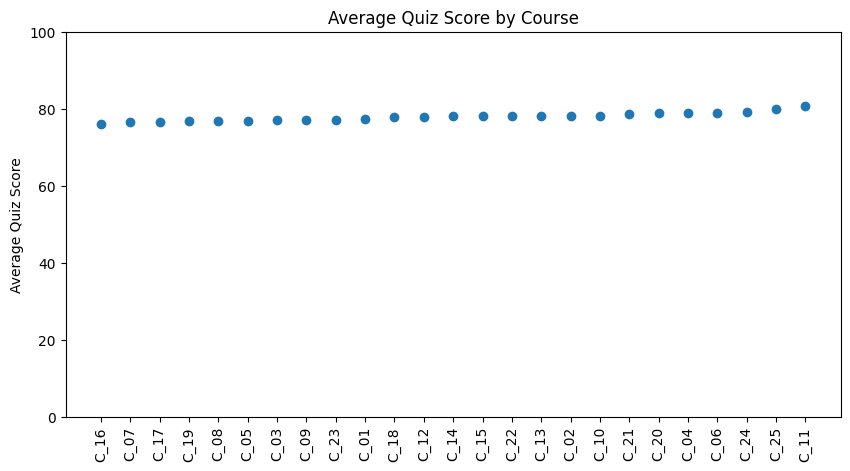

In [16]:
#Plotting a scatter chart for quiz_score per course

plt.figure(figsize=(10,5))
plt.scatter(course_quiz.index, course_quiz.values)
plt.ylabel('Average Quiz Score')
plt.title('Average Quiz Score by Course')
plt.xticks(rotation=90)
plt.ylim(0, 100) 
plt.savefig('Avg_Quiz_Score_by_Course.png')
plt.show()

In [17]:
# Group by course_id and look at average score_improvement per course

course_improvement = data.groupby('course_id')['avg_score_improvement'].mean().sort_values()
print(course_improvement)

course_id
C_17    25.687680
C_15    25.867773
C_16    26.048037
C_08    26.102087
C_18    26.194425
C_11    26.519836
C_03    26.589322
C_09    26.613494
C_13    26.647783
C_10    26.783335
C_07    27.020287
C_21    27.083180
C_06    27.127179
C_25    27.161113
C_19    27.180272
C_24    27.214582
C_01    27.329954
C_22    27.334252
C_23    27.447330
C_02    27.546286
C_20    27.556065
C_14    28.031890
C_12    28.073917
C_04    28.101795
C_05    28.445458
Name: avg_score_improvement, dtype: float64


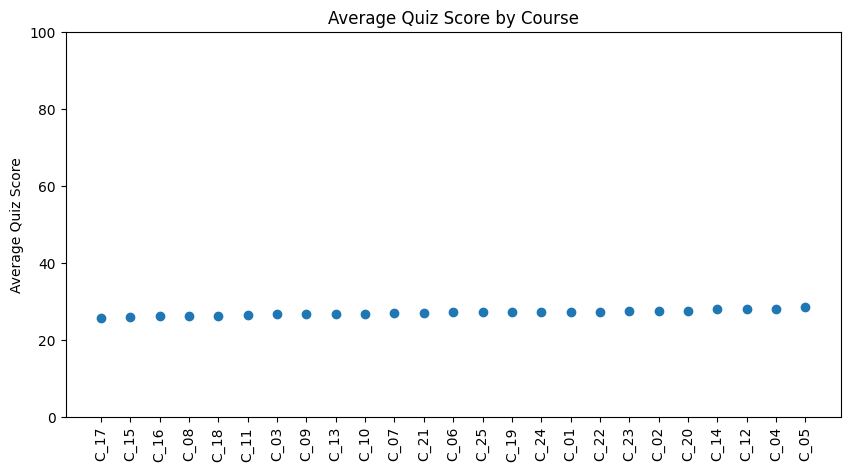

In [18]:
#Plotting a scatter chart for imporvement_score per course

plt.figure(figsize=(10,5))
plt.scatter(course_improvement.index, course_improvement.values)
plt.ylabel('Average Improvement Score')
plt.title('Average Improvement Score by Course')
plt.xticks(rotation=90)
plt.ylim(0, 100) 
plt.savefig('Avg_improvement_Score_by_Course.png')
plt.show()

### Course-Level Effects

To check whether course difficulty confounds the outcome metrics used in the 
effectiveness score, I compared average `completion_rate`, `avg_quiz_score`, 
and `avg_score_improvement` across all 25 courses.

- `completion_rate` ranged from 0.562 to 0.639 across courses (spread ~0.077)
- `avg_quiz_score` ranged from 76.15 to 80.61 across courses (spread ~4.5, 
  on a 0-100 scale)
- `avg_score_improvement` ranged from ~25 to ~28 across courses (spread ~3, 
  on a scale roughly 5-40)

All three outcome metrics show narrow variation across courses relative to 
their own scale, suggesting courses in this dataset are roughly comparable 
in difficulty. Since three independent metrics all support this, course-level 
difficulty does not appear to meaningfully confound instructor outcomes — 
comparisons between instructors can be made directly without course-level 
normalization.

## Instructor level Variability in metrics

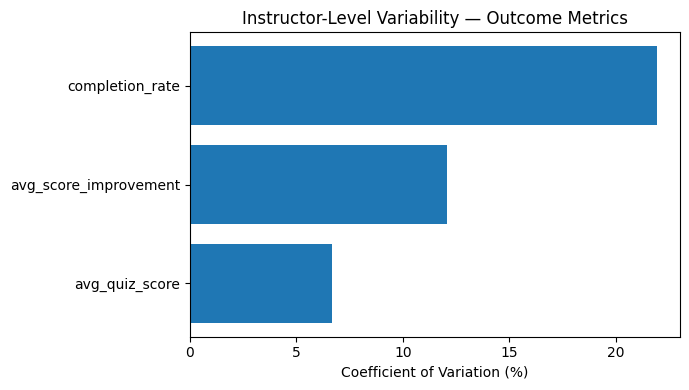

In [19]:
# Using covariance to visualize variability  in instructor_id-grouped data 

outcome_cv = {}
for col in ['completion_rate', 'avg_score_improvement', 'avg_quiz_score']:
    g = data.groupby('instructor_id')[col].mean()
    outcome_cv[col] = (g.std() / g.mean()) * 100

outcome_cv_series = pd.Series(outcome_cv).sort_values()

plt.figure(figsize=(7,4))
plt.barh(outcome_cv_series.index, outcome_cv_series.values)
plt.xlabel('Coefficient of Variation (%)')
plt.title('Instructor-Level Variability — Outcome Metrics')
plt.tight_layout()
plt.savefig('Instructor-Level Variability — Outcome Metrics.png')
plt.show()


### Instructor-Level Variability: Outcome Metrics

To assess how well each outcome metric discriminates between instructors, 
I calculated the coefficient of variation (CV = std/mean) of instructor-level 
averages for `completion_rate`, `avg_score_improvement`, and `avg_quiz_score`.

`completion_rate` shows the highest relative variability between instructors 
(CV ~21.9%), followed by `avg_score_improvement`, with `avg_quiz_score` 
showing the least. This suggests completion_rate is the most discriminative 
outcome metric for separating instructor effectiveness, which supports 
giving it meaningful weight within the outcomes bucket alongside 
avg_score_improvement.

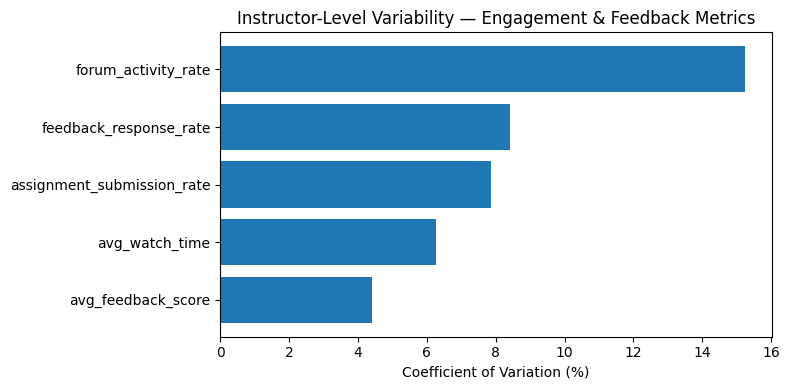

In [20]:
eng_feed_cv = {}
for col in ['avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate',
            'avg_feedback_score', 'feedback_response_rate']:
    g = data.groupby('instructor_id')[col].mean()
    eng_feed_cv[col] = (g.std() / g.mean()) * 100

eng_feed_cv_series = pd.Series(eng_feed_cv).sort_values()

plt.figure(figsize=(8,4))
plt.barh(eng_feed_cv_series.index, eng_feed_cv_series.values)
plt.xlabel('Coefficient of Variation (%)')
plt.title('Instructor-Level Variability — Engagement & Feedback Metrics')
plt.tight_layout()
plt.savefig('Instructor-Level Variability — Engagement & Feedback Metrics.png')
plt.show()


### Engagement & Feedback: Course and Instructor-Level Variability

To match the scrutiny applied to outcome metrics, I checked whether course 
difficulty confounds engagement and feedback metrics, and whether these 
metrics vary meaningfully between instructors.

**Course-level**: All five metrics show narrow ranges across courses 
(e.g., avg_watch_time: 0.742–0.802; avg_feedback_score: 4.105–4.315), 
consistent with the outcome metrics — course difficulty does not appear 
to confound engagement or feedback either.

**Instructor-level (CV)**: `forum_activity_rate` shows the highest relative 
variability between instructors (CV ~15.3%), while `avg_feedback_score` 
shows the lowest (~4.4%). This suggests forum activity differs more 
meaningfully between instructors, while feedback scores tend to cluster 
closely regardless of instructor — most learners rate instructors similarly 
on the 1–5 scale, limiting how much this metric can separate effectiveness 
tiers on its own.

### Assigning Sub-Weights Within Each Bucket

Sub-weights within each bucket were assigned based on instructor-level CV, 
with more discriminative metrics (higher CV) given greater weight:

- **Outcomes (40%)**: `completion_rate` 25% (CV ~21.9%), `avg_score_improvement` 
  10%, `avg_quiz_score` 5% (least discriminative of the three)
- **Engagement (30%)**: `forum_activity_rate` 15% (CV ~15.3%, most 
  discriminative), `assignment_submission_rate` 10%, `avg_watch_time` 5%
- **Feedback (30%)**: `feedback_response_rate` 20% (CV ~8.4%), 
  `avg_feedback_score` 10% (CV ~4.4%, least discriminative overall)

A higher CV reflects discriminative power — how well a metric separates 
instructors from one another — not necessarily instructor skill on its own. 
Since course-level checks confirmed none of these metrics are confounded by 
course difficulty, the instructor-level variability can reasonably be 
treated as a signal of genuine differences between instructors rather than 
noise or a course-driven artifact.

count    120.000000
mean      16.666667
std        4.582270
min        7.000000
25%       13.750000
50%       17.000000
75%       19.000000
max       31.000000
dtype: float64


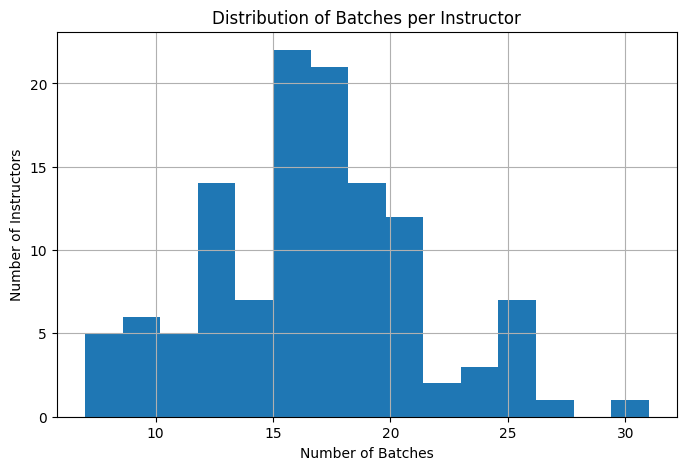

In [21]:
# Distribution of the Number of Batches Taught per Instructor

batch_counts = data.groupby('instructor_id').size()
print(batch_counts.describe())

plt.figure(figsize=(8,5))
batch_counts.hist(bins=15)
plt.xlabel('Number of Batches')
plt.ylabel('Number of Instructors')
plt.title('Distribution of Batches per Instructor')
plt.savefig('Distribution_of_Batches_per_Instructor.png')
plt.show()

### Batches per Instructor

Batch counts per instructor range from 7 to 31 (mean ~16.7, median 17, 
std ~4.6) across 120 instructors. Most instructors teach between 14 and 
20 batches. The distribution is roughly bell-shaped with a slight right 
skew, driven by a small number of instructors teaching notably more 
batches than average.

Since even the lowest-count instructors have a reasonably sized sample 
(minimum 7 batches), no special shrinkage or smoothing is needed when 
aggregating to the instructor level — a simple mean should be stable 
enough. However, `batch_count` itself may carry useful signal about the 
reliability of an instructor's aggregated metrics, so it will be 
considered as a potential feature in modeling.

## EDA Summary

Across the exploratory analysis, several patterns emerged that directly 
inform how instructor effectiveness is defined and weighted:

1. **Distributions**: Most metrics (avg_quiz_score, avg_feedback_score, 
   avg_score_improvement) are reasonably well-behaved and roughly bell-shaped. 
   `avg_watch_time` is notably skewed, with many batches clustered near the 
   ceiling (close to 1.0), limiting its ability to distinguish instructors. 
   `completion_rate` shows small spikes near both its minimum and maximum.

2. **Correlations**: `completion_rate` and `dropout_rate` are strongly 
   negatively correlated (-0.95), indicating redundant information — 
   `dropout_rate` was excluded going forward. All other metric pairs show 
   weak-to-moderate correlations (mostly 0.1–0.4), suggesting the remaining 
   features carry relatively independent signal.

3. **Course-level effects**: For both outcome metrics (completion_rate, 
   avg_quiz_score, avg_score_improvement) and engagement/feedback metrics 
   (avg_watch_time, assignment_submission_rate, forum_activity_rate, 
   avg_feedback_score, feedback_response_rate), average values varied only 
   narrowly across the 25 courses relative to each metric's own scale. This 
   suggests course difficulty does not meaningfully confound any of these 
   metrics, so instructor comparisons can be made directly without 
   course-level normalization.

4. **Instructor-level variability**: Since the metrics used for course-level 
   checks sit on different scales, discriminative power between instructors 
   was assessed separately using the coefficient of variation (CV = std/mean), 
   which expresses spread as a scale-independent percentage — unlike the 
   course-level checks, where comparing a metric only against itself made 
   raw range sufficient. Among outcome metrics, `completion_rate` showed the 
   highest relative variability between instructors, indicating strong 
   discriminative power; `avg_quiz_score` showed the least. Among engagement 
   and feedback metrics, `forum_activity_rate` was the most discriminative 
   (CV ~15.3%), while `avg_feedback_score` was the least (CV ~4.4%), meaning 
   most instructors receive similar feedback ratings regardless of actual 
   effectiveness.

5. **Batches per instructor**: Batch counts range from 7 to 31 per instructor 
   (mean ~16.7, median 17), with most instructors teaching 14–20 batches. 
   Since even the lowest-count instructors have a reasonably sized sample, 
   no special shrinkage is needed for aggregation — a simple mean should be 
   stable. `batch_count` itself may still carry useful signal about the 
   reliability of an instructor's aggregated metrics and will be considered 
   as a potential feature.

**Overall**: the dataset is clean, features are largely independent, and 
course difficulty does not meaningfully confound any metric used in the 
effectiveness score. However, metrics vary in how well they actually 
discriminate between instructors — a consideration that will inform relative 
weighting within each bucket (outcomes, engagement, feedback) in the next step.

# Section 3: Defining Instructor Effectiveness

There is no single, objective measure of "instructor effectiveness" in this 
dataset — it has to be constructed from the available proxies for learner 
outcomes, engagement, and feedback. This section defines that construction 
and justifies each choice.

### Choosing the Buckets and Top-Level Weights

I grouped the 8 retained metrics (excluding `dropout_rate`, dropped earlier 
due to redundancy with `completion_rate`) into three buckets:

- **Outcomes (40%)**: completion_rate, avg_score_improvement, avg_quiz_score
- **Engagement (30%)**: avg_watch_time, assignment_submission_rate, forum_activity_rate
- **Feedback (30%)**: avg_feedback_score, feedback_response_rate

Outcomes were weighted highest because they most directly reflect whether 
learners actually finished and improved — the core goal of a course — while 
engagement and feedback are important but somewhat more indirect indicators 
of instructor quality.

### Assigning Sub-Weights Within Each Bucket

Sub-weights within each bucket were assigned based on instructor-level CV 
(coefficient of variation = std/mean), with more discriminative metrics 
(higher CV) given greater weight:

- **Outcomes (40%)**: `completion_rate` 25% (CV ~21.9%, most discriminative), 
  `avg_score_improvement` 10%, `avg_quiz_score` 5% (least discriminative)
- **Engagement (30%)**: `forum_activity_rate` 15% (CV ~15.3%, most 
  discriminative), `assignment_submission_rate` 10%, `avg_watch_time` 5%
- **Feedback (30%)**: `feedback_response_rate` 20% (CV ~8.4%), 
  `avg_feedback_score` 10% (CV ~4.4%, least discriminative overall)

A higher CV reflects discriminative power — how well a metric separates 
instructors from one another — not necessarily instructor skill on its own. 
Since course-level checks (see EDA) confirmed none of these metrics are 
confounded by course difficulty, the instructor-level variability can 
reasonably be treated as a signal of genuine differences between instructors 
rather than noise or a course-driven artifact.

### Normalization

All metrics were normalized using min-max scaling, chosen because the 
metrics already have natural, meaningful bounds (0–1 rates, 1–5 feedback 
score), and min-max keeps the resulting composite score interpretable on a 
common 0–1 scale — which maps directly onto the tiering step that follows. 
Normalization is applied **after** aggregating batches to instructor level 
(Step 3), rather than on raw batch-level data, since the goal is to compare 
instructors against each other, not individual batches against the full 
batch pool.

### Tiering

Once instructors have a single composite effectiveness score (0–1), they are 
split into Low / Medium / High tiers using quantile-based binning (equal-sized 
groups by rank), rather than fixed score thresholds. This avoids relying on 
arbitrary cutoffs and helps prevent severe class imbalance going into the 
classification model in Step 4.

# Section 4: Aggregate Batch Data to Instructor Level

Since each instructor teaches multiple batches (ranging from 7 to 31 in this 
dataset), batch-level rows need to be collapsed into a single instructor-level 
row before the effectiveness score or model can be built.

### Aggregation Function: Median

All 8 metrics were aggregated per instructor using the **median**, rather 
than the mean. Median was chosen because it is more robust to any single 
atypical batch — for example, a batch affected by a technical issue, an 
unusually weak cohort, or a one-off scheduling problem — which could 
otherwise pull an instructor's average away from what is representative of 
their typical performance. Since the goal is to capture an instructor's 
*typical* effectiveness rather than their performance in any one batch, 
median better reflects the "central tendency" of their teaching without 
letting outlier batches dominate.

### Handling Instructors with Few vs. Many Batches

Earlier EDA showed that batch counts per instructor range from 7 to 31, with 
a mean of ~16.7 and median of 17 (std ~4.6) — see *Batches per Instructor* 
above. Two implications follow from this:

- **Few-batch instructors**: even the lowest-count instructors have 7 
  batches, which is enough to compute a reasonably stable median without 
  needing more aggressive techniques such as shrinkage toward the overall 
  mean (a common approach when some instructors have only 1–2 data points). 
  Because no instructor in this dataset has an extremely small sample, no 
  such adjustment was applied.

- **Many-batch instructors**: instructors with unusually high batch counts 
  (e.g., 25+) aren't given any extra weight or special treatment in this 
  aggregation — median treats all of an instructor's batches equally 
  regardless of how many there are. However, since batch count itself may 
  reflect something meaningful (e.g., more experienced or more frequently 
  assigned instructors), it was retained as a separate feature 
  (`batch_count`) rather than folded into the effectiveness score, so the 
  model can learn from it independently if it turns out to matter.


In [24]:
# Aggregate batch-level metrics to instructor level using median

metrics = ['completion_rate', 'avg_score_improvement', 'avg_quiz_score',
           'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate',
           'avg_feedback_score', 'feedback_response_rate']

instructor_df = data.groupby('instructor_id')[metrics].median()

# Add batch_count as a separate feature

instructor_df['batch_count'] = data.groupby('instructor_id').size()

instructor_df.head()

,completion_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,batch_count
instructor_id,,,,,,,,,
I_001,0.545357,26.112106,78.961710,0.733658,0.738582,0.251056,4.249951,0.655761,25
I_002,0.723018,30.453036,77.930867,0.853840,0.762905,0.287592,4.246529,0.795214,20
I_003,0.754272,29.786063,83.114009,0.825693,0.757713,0.304923,4.429999,0.773348,18
I_004,0.431807,21.240292,75.573381,0.785699,0.748872,0.229930,4.056810,0.694328,17
I_005,0.871484,32.768176,86.624262,0.871003,0.864285,0.328823,4.223685,0.794441,19


In [29]:
from sklearn.preprocessing import MinMaxScaler

# Define weights

weights = {
    'completion_rate': 0.25,
    'avg_score_improvement': 0.10,
    'avg_quiz_score': 0.05,
    'forum_activity_rate': 0.15,
    'assignment_submission_rate': 0.10,
    'avg_watch_time': 0.05,
    'feedback_response_rate': 0.20,
    'avg_feedback_score': 0.10,
}

# Min-max normalize each metric at the instructor level

scaler = MinMaxScaler()
normalized = pd.DataFrame(
    scaler.fit_transform(instructor_df[list(weights.keys())]),
    columns=list(weights.keys()),
    index=instructor_df.index
)

# Compute weighted composite score

instructor_df['effectiveness_score'] = sum(
    normalized[col] * w for col, w in weights.items()
)

# Quantile-based tiering into 3 equal-sized groups

instructor_df['effectiveness_tier'] = pd.qcut(
    instructor_df['effectiveness_score'], q=3, labels=['Low', 'Medium', 'High']
)

instructor_df[['effectiveness_score', 'effectiveness_tier']].head(10)

,effectiveness_score,effectiveness_tier
instructor_id,,
I_001,0.422383,Low
I_002,0.629013,High
I_003,0.659748,High
I_004,0.342454,Low
I_005,0.768330,High
I_006,0.247308,Low
I_007,0.617164,High
I_008,0.570406,High
I_009,0.559392,High


In [27]:
instructor_df['effectiveness_tier'].value_counts()

effectiveness_tier
Low       40
Medium    40
High      40
Name: count, dtype: int64

### Composite Effectiveness Score and Tiering

Instructor-level metrics were min-max normalized, then combined using the 
weights defined earlier to produce a composite effectiveness score (0–1) 
per instructor. Instructors were split into three equal-sized tiers (Low, 
Medium, High) using quantile-based binning, resulting in a perfectly 
balanced 40/40/40 split — avoiding class imbalance in the model that follows.

### Resulting Structure

The aggregation produces a 120-row dataframe (one row per instructor), with 
median values for all 8 retained metrics plus `batch_count`, forming the 
basis for the composite effectiveness score and the modeling dataset in 
Step 4.

# Section 5: Machine Learning Model

In [31]:
# feature set, train/test split

from sklearn.model_selection import train_test_split

feature_cols = ['completion_rate', 'avg_score_improvement', 'avg_quiz_score',
                'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate',
                'avg_feedback_score', 'feedback_response_rate', 'batch_count']

X = instructor_df[feature_cols]
y = instructor_df['effectiveness_tier']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

(96, 9) (24, 9)
effectiveness_tier
Low       32
Medium    32
High      32
Name: count, dtype: int64
effectiveness_tier
Low       8
Medium    8
High      8
Name: count, dtype: int64


In [32]:
# Using RandomForestClassifier Algorithm

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

        High       1.00      0.75      0.86         8
         Low       0.88      0.88      0.88         8
      Medium       0.70      0.88      0.78         8

    accuracy                           0.83        24
   macro avg       0.86      0.83      0.84        24
weighted avg       0.86      0.83      0.84        24

[[6 0 2]
 [0 7 1]
 [0 1 7]]


# Section 6: Evaluating the Model

### Metrics Used

Since this is a multi-class classification problem with balanced classes 
(32/32/32 in training, 8/8/8 in test — a direct result of the quantile-based 
tiering in Step 2), accuracy is a reasonably fair headline metric here, unlike 
in many real-world classification problems where imbalance makes accuracy 
misleading. Even so, precision, recall, and F1 per class give a more complete 
picture of where the model succeeds and fails.

**Overall accuracy: 83%** (20/24 correct on the held-out test set).

### Per-Tier Performance

- **High**: Precision 1.00, Recall 0.75 — every instructor the model labeled 
  "High" was genuinely High (no false positives), but it missed 2 of the 8 
  true High instructors, mislabeling them as Medium. The model is 
  conservative about the High label, only assigning it when confident.
- **Low**: Precision 0.88, Recall 0.88 — the strongest, most balanced tier.
- **Medium**: Precision 0.70, Recall 0.88 — Medium captures the most 
  ambiguous cases, including the missed High and Low instructors, making it 
  something of a "catch-all" for borderline profiles between the two 
  extremes.

### Confusion Matrix Insight

Critically, **no instructor was ever confused between High and Low directly** 
— every misclassification involved Medium as one side of the error 
(High→Medium or Low→Medium, never High→Low or Low→High). This suggests the 
model's mistakes are "near-miss" errors along a continuous effectiveness 
spectrum, rather than serious, large errors — a reassuring pattern given the 
effectiveness score itself was built as a continuous composite before being 
split into discrete tiers.

### Trade-off Discussion

For a real-world use case, the more consequential error type is likely 
**missing a genuinely High-performing instructor** (labeling them Medium) 
rather than mistakenly promoting a Low performer, since the latter never 
occurred here. If the business wanted to prioritize *catching all* strong 
instructors (e.g., for recognition or mentorship programs) even at the risk 
of a few false positives, recall on the High tier could be improved by 
adjusting the classification threshold or gathering more training data — 
though with only 120 instructors total, some of the current uncertainty may 
simply reflect natural boundary ambiguity rather than a model deficiency.

### Class Imbalance

No class imbalance is present in this dataset, since instructor tiers were 
constructed using quantile-based binning, which guarantees equal-sized 
groups by design. This is a deliberate methodological choice made in Step 2, 
not an incidental property of the raw data.

##  Feature importances

completion_rate               0.328699
avg_score_improvement         0.189734
feedback_response_rate        0.161032
avg_quiz_score                0.101921
assignment_submission_rate    0.058063
avg_feedback_score            0.053915
avg_watch_time                0.048477
forum_activity_rate           0.038111
batch_count                   0.020049
dtype: float64


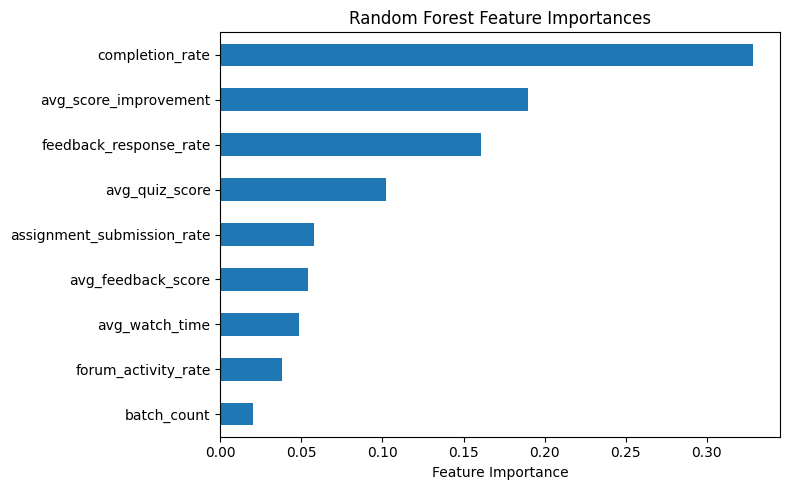

In [35]:
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances)

plt.figure(figsize=(8,5))
importances.plot(kind='barh')
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('RandomForestFeatureImportances.png')
plt.show()

# Section 7: Interpreting the Results

### Key Features Driving Instructor Effectiveness

The Random Forest's feature importances largely align with the reasoning 
used to build the effectiveness score, with one notable exception:

- **completion_rate** was both the most heavily weighted metric (25%) and 
  the most important feature for the model (importance 0.329) — the 
  strongest, most consistent signal across both the manually-constructed 
  score and the model's independent learning process.
- **avg_score_improvement** and **feedback_response_rate** were the next 
  most important features (0.190 and 0.161), broadly consistent with their 
  relatively high assigned weights (10% and 20%).
- **forum_activity_rate**, despite being weighted at 15% (based on having 
  the highest CV among engagement metrics), ranked among the *least* 
  important features for the model (0.038). This reveals a limitation of 
  using CV alone to assign weights: CV measures how much a metric varies 
  between instructors, but not how well that variation aligns with the 
  overall effectiveness construct being predicted. A metric can vary a lot 
  between instructors without that variation being predictive of the final 
  tier, if it doesn't correlate with the other metrics driving the 
  composite score.
- **batch_count** had the lowest importance of all features (0.020), 
  confirming that the number of batches an instructor taught carries little 
  independent signal about their effectiveness tier in this dataset.

### Summary

In simple terms: instructors are most reliably distinguished by whether 
learners actually **complete** their courses and **improve** their scores — 
these two factors matter far more than engagement signals like forum 
activity or watch time. Learner feedback response rate (how many learners 
bother to leave feedback at all) also matters more than the actual average 
feedback score, suggesting that getting learners to engage with feedback 
at all may be a more telling signal than the rating itself.

### Product Implications

These findings suggest an EdTech platform could:
- Prioritize completion and score-improvement data as the primary signals 
  in any instructor-facing dashboard or early-warning system, since these 
  are the most predictive of overall effectiveness.
- Treat forum activity and average feedback score as supplementary, 
  lower-priority signals — useful for context, but not strong standalone 
  indicators of instructor quality.
- Investigate *why* feedback response rate matters more than the score 
  itself — it may indicate learner engagement or trust in the platform 
  more broadly, which is a separate but related signal worth exploring.

# Section 8: Important Questions regarding the model

**1. Which features most influenced instructor effectiveness, and why?**

`completion_rate` was both the most heavily weighted metric in my composite 
score (25%) and the most important feature according to the model (importance 
0.329) — the strongest, most consistent signal across both the manually 
constructed score and the model's independent learning process. Two separate 
reasons support relying on it: first, it showed the highest instructor-level 
CV among outcome metrics, meaning it meaningfully distinguishes instructors 
from one another; second, and separately, course-level checks showed 
completion_rate varies only narrowly across the 25 courses (0.562–0.639), 
meaning it isn't confounded by course difficulty in this dataset — so 
differences in completion_rate between instructors can be fairly attributed 
to instructor performance rather than which course they happened to teach. 
`avg_score_improvement` and `feedback_response_rate` were the next most 
important features, also broadly consistent with their assigned weights, 
reinforcing that outcome-related and engagement-follow-through metrics 
matter more than raw activity or sentiment measures.

**2. Which variables could be misleading or confounded?**

`forum_activity_rate` is a good example of a variable that can be misleading 
even without being confounded by course difficulty. It had the highest CV 
among engagement metrics (~15.3%), suggesting strong variability between 
instructors, which led me to weight it at 15% in the composite score. 
However, the trained model ranked it among the least important features 
(importance 0.038) for predicting the actual effectiveness tier. This shows 
that high variability between instructors doesn't guarantee that variability 
is meaningful for effectiveness — forum activity could instead reflect 
factors unrelated to instructor skill, such as a course topic naturally 
generating more discussion, or differing communication styles that don't 
correlate with actual teaching quality. This is a case where my own 
assumption (higher CV implies a more useful metric) didn't fully hold, and 
it highlights the risk of assigning weights based on statistical spread 
alone without checking whether that spread aligns with the broader construct 
being measured.

**3. How could this model fail in real-world usage?**

One limitation is specific to this dataset: course-level checks showed very 
narrow variation in outcomes across the 25 courses here (e.g., completion_rate 
spread of only ~0.077). This is convenient for comparing instructors directly, 
but it may not hold on a real EdTech platform, where courses often do differ 
meaningfully in difficulty, subject matter, or learner population. A model 
trained on this dataset might not generalize well to a platform where course 
difficulty genuinely confounds instructor performance, and would need 
retraining or explicit course-adjustment if deployed elsewhere.

Beyond that, other real-world failure modes include: instructors adjusting 
their behavior once they know which metrics are measured (e.g., over-focusing 
on completion_rate at the expense of teaching depth); new instructors with very few batches producing unstable aggregated 
metrics, even though batch counts in this dataset were reasonably healthy; 
and the model having no way to capture qualities of good teaching that simply 
aren't present in this data, such as clarity of communication, fairness, or 
responsiveness to struggling learners.

**4. What additional data would you want to improve this analysis?**

- Learner-level data (prior academic ability, demographics) to separate an 
  instructor's actual impact from the composition of the learners they 
  happened to teach.
- Qualitative feedback (open-text comments), not just a 1–5 rating, to 
  capture nuance a single feedback score can't.
- Longitudinal data on the same instructor over time, to see whether 
  effectiveness is stable or improves/declines, rather than a single 
  snapshot.
- Same-instructor, different-course comparisons, to more directly isolate 
  instructor skill from course-specific effects, rather than relying on 
  cross-instructor course-level averages as a proxy.
- Data on class size or learner-to-instructor ratio, which could meaningfully 
  affect engagement and outcome metrics independent of instructor quality.

**5. Should this model be used for instructor performance evaluation? Why or why not?**

Not on its own, and not without caution. While the model performs reasonably 
well (83% accuracy, no High↔Low confusion), several factors argue against 
using it directly for real evaluation decisions: there is no ground-truth 
label for "true" instructor effectiveness — the target itself was constructed 
from proxy metrics and my own weighting choices, so the model is learning to 
predict *my definition* of effectiveness, not an objective one. The dataset 
is also small (120 instructors), and one metric (forum_activity_rate) already 
showed a mismatch between assumed and actual importance, suggesting other 
proxies in the score could be similarly imperfect. Finally, using this kind 
of score for real evaluation risks instructors optimizing 
for measured metrics (e.g., completion_rate) rather than genuine teaching 
quality, once they know how they're being scored.

A more responsible use of this model would be as a **supporting signal** — 
e.g., flagging instructors for further qualitative review — rather than as 
a sole or automated basis for performance decisions.